### 데이터 다운로드 및 이상치 개수 확인

In [1]:
import pandas as pd

df = pd.read_csv('card_transdata.csv')
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [2]:
df

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
907276,1.353139,2.196245,0.415683,0.0,0.0,0.0,1.0,0.0
907277,153.840850,0.083693,0.436275,1.0,0.0,1.0,0.0,0.0
907278,4.140821,11.756735,1.025066,1.0,1.0,0.0,1.0,0.0
907279,53.663349,1.430100,3.321645,1.0,0.0,0.0,1.0,0.0


In [2]:
df[df['fraud']==0.0].shape[0]

827817

In [3]:
df[df['fraud']==1.0].shape[0]

79463

#### 

### 극단적인 데이터 불균형 상황 가정 
fraud를 기준으로 일반 거래(fraud==0.0) 데이터는 50,000개, 사기 거래(fraud==1.0)sms 1,000개로 조정

In [4]:
# 정상(0.0)과 이상(1.0) 데이터 나누기
df_normal = df[df['fraud'] == 0.0]
df_anomaly = df[df['fraud'] == 1.0]

# 샘플링
df_normal_sampled = df_normal.sample(n=50000, random_state=42)
df_anomaly_sampled = df_anomaly.sample(n=1000, random_state=42)

# 합치기
df_sampled = pd.concat([df_normal_sampled, df_anomaly_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

df_sampled.shape


(51000, 8)

In [5]:
df_sampled[df_sampled['fraud']==0.0].shape[0]

50000

In [6]:
df_sampled[df_sampled['fraud']==1.0].shape[0]

1000

#### 

### 데이터 EDA

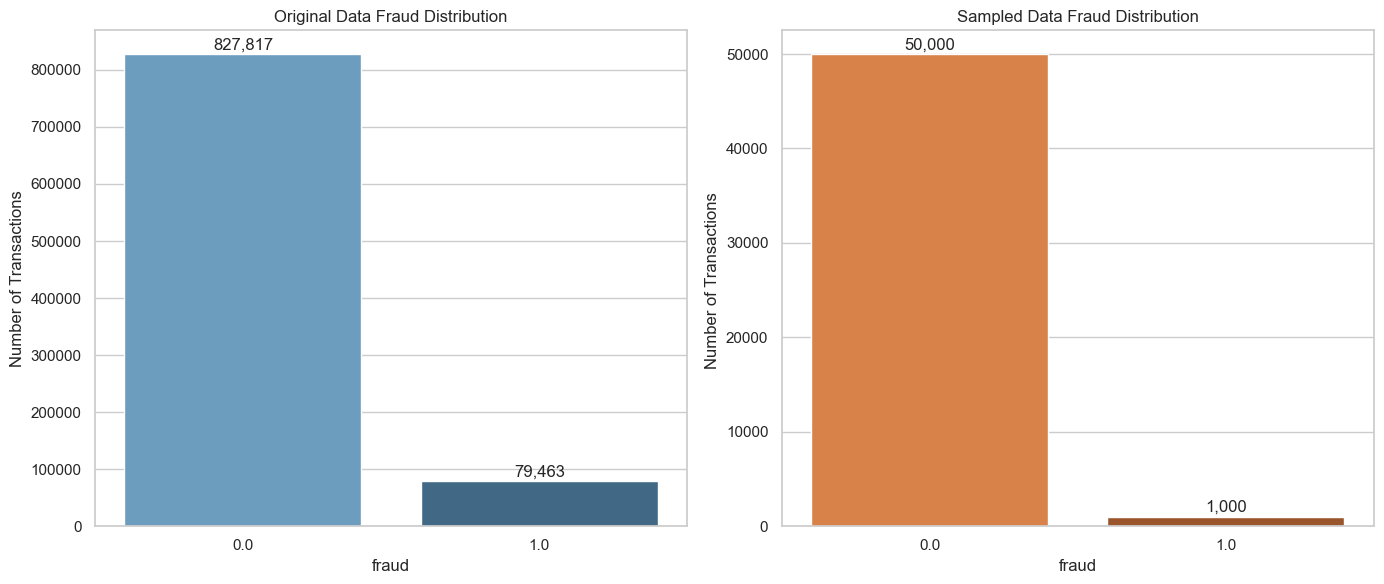

In [15]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import matplotlib.font_manager as fm
import warnings

# ===== 경고 숨기기 =====
warnings.filterwarnings("ignore")

# ===== 1. Windows용 한글 폰트 안전 적용 =====
font_path = None
for f in fm.fontManager.ttflist:
    if f.name == 'Malgun Gothic':
        font_path = f.fname
        break

if font_path:
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = font_prop.get_name()
else:
    plt.rcParams['font.family'] = 'Arial'  # fallback
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

# ===== 2. Seaborn 스타일 적용 (폰트 설정 후) =====
sns.set(style="whitegrid")

# ===== 3. 데이터 준비 =====
fraud_counts_orig = df['fraud'].value_counts().sort_index()
fraud_counts_sampled = df_sampled['fraud'].value_counts().sort_index()

# ===== 4. Figure와 axes 생성 (가로 2개) =====
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ===== (a) 원본 데이터 =====
sns.barplot(x=fraud_counts_orig.index, y=fraud_counts_orig.values, ax=axes[0], palette="Blues_d")
axes[0].set_title("Original Data Fraud Distribution", fontname=plt.rcParams['font.family'])
axes[0].set_xlabel("fraud", fontname=plt.rcParams['font.family'])
axes[0].set_ylabel("Number of Transactions", fontname=plt.rcParams['font.family'])
for i, v in enumerate(fraud_counts_orig.values):
    axes[0].text(i, v + max(fraud_counts_orig.values)*0.01, f"{v:,}", ha='center', fontname=plt.rcParams['font.family'])

# ===== (b) 샘플링 데이터 =====
sns.barplot(x=fraud_counts_sampled.index, y=fraud_counts_sampled.values, ax=axes[1], palette="Oranges_d")
axes[1].set_title("Sampled Data Fraud Distribution", fontname=plt.rcParams['font.family'])
axes[1].set_xlabel("fraud", fontname=plt.rcParams['font.family'])
axes[1].set_ylabel("Number of Transactions ", fontname=plt.rcParams['font.family'])
for i, v in enumerate(fraud_counts_sampled.values):
    axes[1].text(i, v + max(fraud_counts_sampled.values)*0.01, f"{v:,}", ha='center', fontname=plt.rcParams['font.family'])

# ===== 5. Layout 조정 =====
plt.tight_layout()
plt.show()



===== 📌 샘플링 데이터 (51,000행) 기본 정보 =====
shape: (51000, 8)

▶ 상위 5개 샘플:
 distance_from_home  distance_from_last_transaction  ratio_to_median_purchase_price  repeat_retailer  used_chip  used_pin_number  online_order  fraud
            22.2028                          1.1409                          0.8100           1.0000     1.0000           0.0000        1.0000 0.0000
            45.9440                          1.5399                          0.5793           1.0000     0.0000           1.0000        1.0000 0.0000
             0.5020                          0.2626                          0.3174           0.0000     1.0000           0.0000        0.0000 0.0000
             2.1826                          0.2385                          1.6799           1.0000     0.0000           0.0000        0.0000 0.0000
             2.2021                          0.2688                          0.6272           1.0000     0.0000           0.0000        0.0000 0.0000

▶ info():
<class 'pandas.core

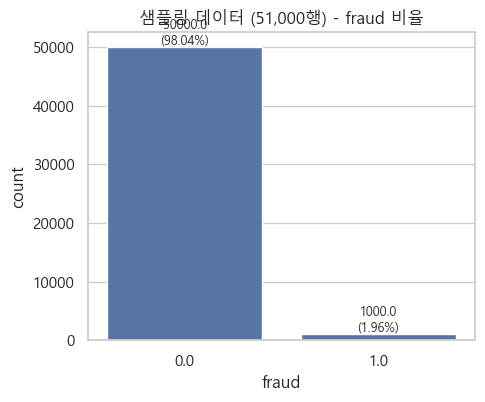

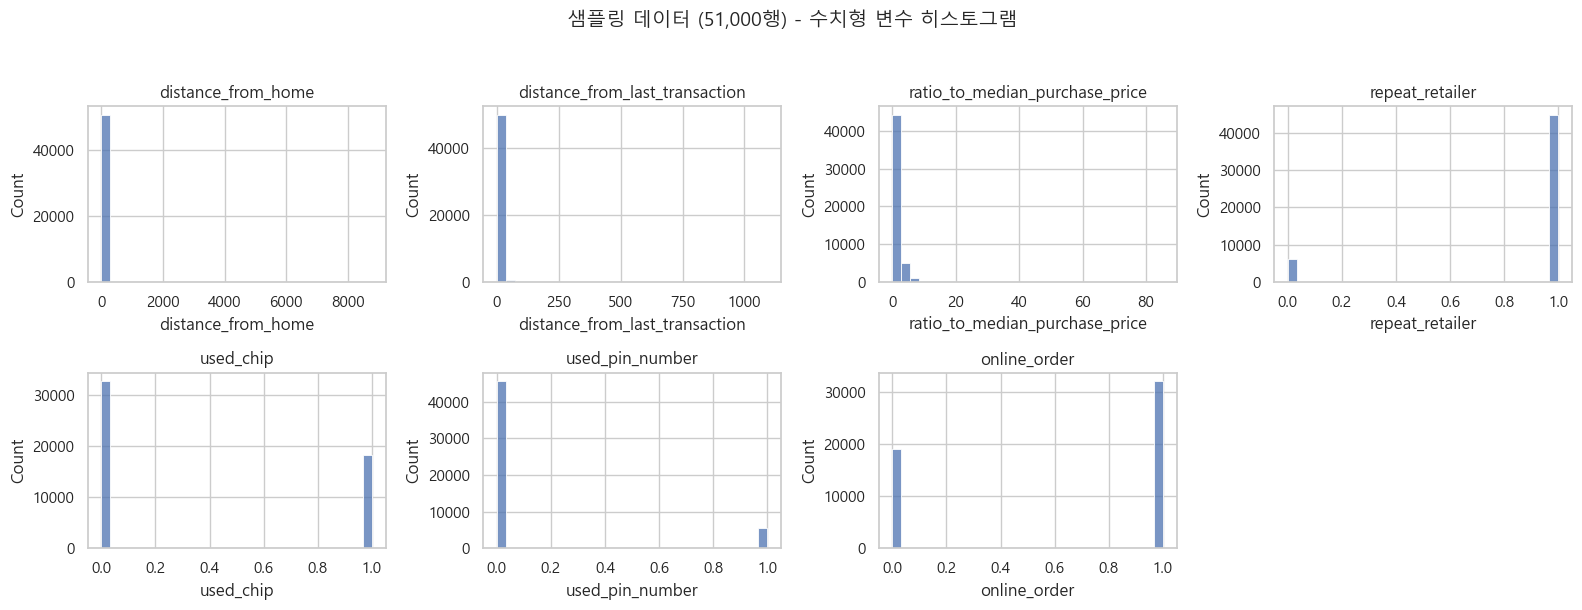

In [ ]:
# 샘플링 데이터셋에 대한 EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib

# ====== 1. 환경 설정: 경고 숨기기, pandas 출력 설정, 시각화 스타일 ======
warnings.filterwarnings("ignore")  # 경고 메시지 숨기기

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f"{x:0.4f}")

sns.set_theme(style="whitegrid")

# ====== 2. 한글 폰트 설정 (여러 OS 대응; 가능한 폰트부터 시도) ======
def set_korean_font():
    korean_fonts = [
        "Malgun Gothic",    # Windows
        "AppleGothic",      # macOS
        "NanumGothic",      # Linux (사용자가 설치한 경우)
        "DejaVu Sans"       # fallback (영문/기본)
    ]
    available = matplotlib.font_manager.findSystemFonts(fontpaths=None, fontext='ttf')
    for name in korean_fonts:
        try:
            matplotlib.rcParams['font.family'] = name
            # 적용 확인: 일부 환경에서는 폰트가 없는데도 설정 성공으로 보일 수 있으므로 예외처리는 불완전함.
            # 문제 발생 시 최종 fallback인 DejaVu Sans로 돌아감
            # matplotlib의 마이너스 기호 문제 처리
            matplotlib.rcParams['axes.unicode_minus'] = False
            return
        except Exception:
            continue
    # fallback
    matplotlib.rcParams['font.family'] = 'DejaVu Sans'
    matplotlib.rcParams['axes.unicode_minus'] = False

set_korean_font()

# ====== 3. EDA 유틸 함수 정의 ======
def basic_info(df, name="Dataset"):
    print(f"\n===== 📌 {name} 기본 정보 =====")
    print("shape:", df.shape)
    print("\n▶ 상위 5개 샘플:")
    print(df.head().to_string(index=False))
    
    print("\n▶ info():")
    df.info()   # buf=None으로 기본 출력
    
    print("\n▶ 결측치 개수 (컬럼별):")
    print(df.isnull().sum())
    
    print("\n▶ 기술 통계 (describe):")
    print(df.describe().T)   # 기술 통계표 출력


def plot_fraud_ratio(df, name="Dataset"):
    plt.figure(figsize=(5,4))
    ax = sns.countplot(x="fraud", data=df)
    total = len(df)
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height}\n({height/total:.2%})', 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9)
    plt.title(f"{name} - fraud 비율")
    plt.xlabel("fraud")
    plt.ylabel("count")
    plt.show()

def numeric_hist(df, name="Dataset", bins=30, max_cols=4):
    numeric_cols = df.select_dtypes(include=["int64","float64","float32","int32"]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "fraud"]
    n = len(numeric_cols)
    if n == 0:
        return
    cols = max_cols
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols*4, rows*3.2))
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(rows, cols, i)
        sns.histplot(df[col], bins=bins, kde=False)
        plt.title(f"{col}")
    plt.suptitle(f"{name} - 수치형 변수 히스토그램", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def boxplot_by_fraud(df, name="Dataset", max_plots=8):
    numeric_cols = df.select_dtypes(include=["int64","float64","float32","int32"]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "fraud"]
    # limit number of plots to avoid too many figures
    numeric_cols = numeric_cols[:max_plots]
    for col in numeric_cols:
        plt.figure(figsize=(6,3.5))
        sns.boxplot(x="fraud", y=col, data=df)
        plt.title(f"{name} - {col} by fraud")
        plt.tight_layout()
        plt.show()

def corr_heatmap(df, name="Dataset", annot=True):
    corr = df.corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=annot, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
    plt.title(f"{name} 상관관계 히트맵")
    plt.show()

def fraud_stats(df, name="Dataset"):
    print(f"\n===== 📌 {name} fraud별 기술통계 (평균, 중앙값) =====")
    mean_tbl = df.groupby("fraud").mean().T
    median_tbl = df.groupby("fraud").median().T
    print("\n▶ 클래스별 평균:")
    print(mean_tbl)
    print("\n▶ 클래스별 중앙값:")
    print(median_tbl)

def pairplot_sample(df, name="Dataset", sample_n=2000, hue="fraud"):
    n_rows = len(df)
    use_n = min(sample_n, n_rows)
    if use_n < 200:
        # 너무 적으면 skip
        print("샘플이 작아서 pairplot을 생략합니다.")
        return
    small = df.sample(use_n, random_state=42)
    sns.pairplot(small, hue=hue, corner=True, plot_kws={'alpha':0.6})
    plt.suptitle(f"{name} Pairplot (샘플 {use_n}개)", y=1.02)
    plt.show()

# ====== 4. 전체 실행 함수 (원본은 pairplot=False 권장) ======
def run_full_eda(df, name="Dataset", do_pairplot=False):
    basic_info(df, name)
    plot_fraud_ratio(df, name)
    numeric_hist(df, name)
    boxplot_by_fraud(df, name)
    corr_heatmap(df, name)
    fraud_stats(df, name)
    if do_pairplot:
        # 위험: 큰 데이터는 내부에서 자동으로 샘플링
        pairplot_sample(df, name)
    else:
        print("\n(참고) pairplot은 계산량이 크므로 기본적으로 비활성화 되어 있습니다. 필요 시 do_pairplot=True로 실행하세요.")
        
# ====== 5. 사용 ======
run_full_eda(df_sampled, name="샘플링 데이터 (51,000행)", do_pairplot=True)

===== Dataset Basic Info =====
Number of samples: 51000
Number of variables: 8

Column names and types:
distance_from_home                float64
distance_from_last_transaction    float64
ratio_to_median_purchase_price    float64
repeat_retailer                   float64
used_chip                         float64
used_pin_number                   float64
online_order                      float64
fraud                             float64
dtype: object

Missing values per column:
distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

===== Descriptive Statistics =====
                                    count    mean     std    min    25%    50%     75%       max
distance_from_home             51000.0000 23.7532 67.7501 0.0277 3.8239 9.7451 24.44

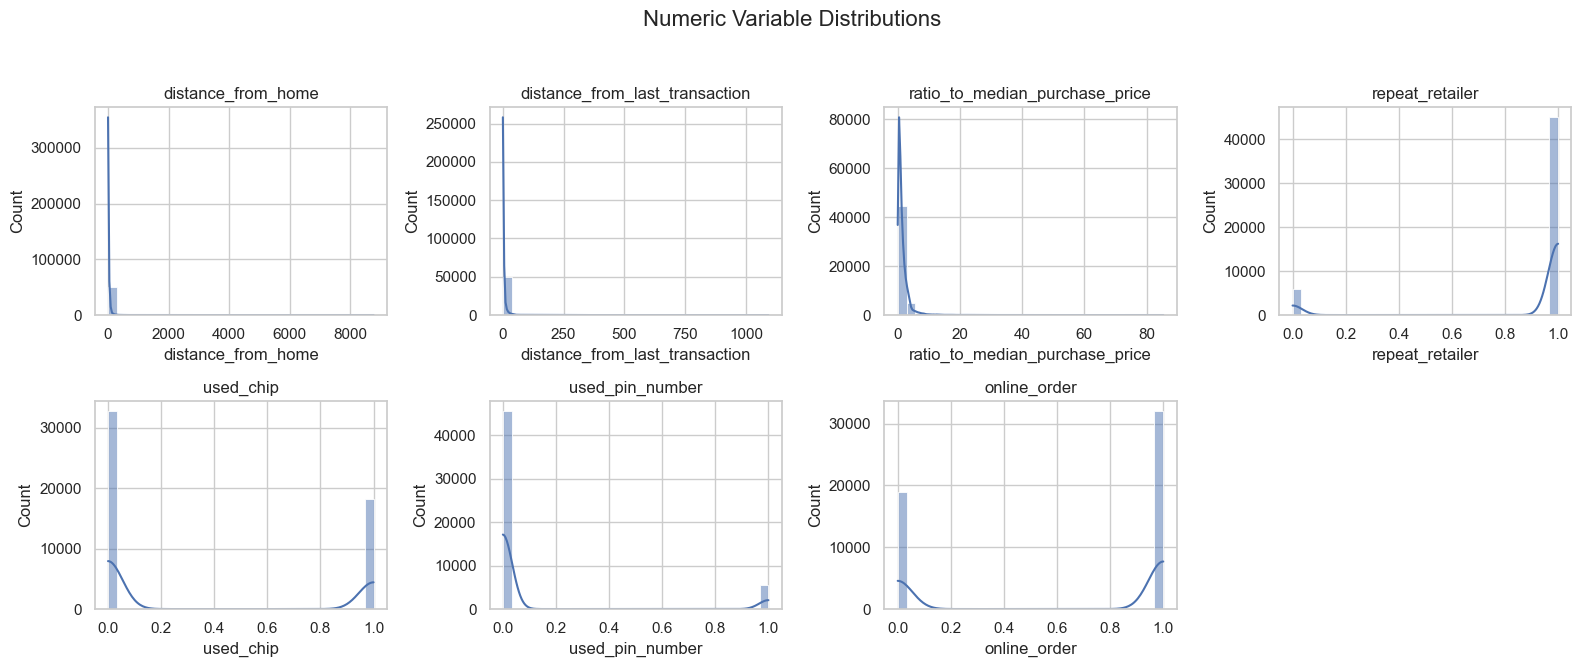

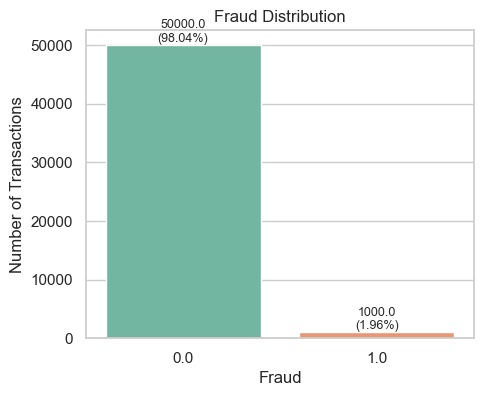

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ===== 환경 설정 =====
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# ===== 1. 데이터 기본 정보 =====
print("===== Dataset Basic Info =====")
print("Number of samples:", df_sampled.shape[0])
print("Number of variables:", df_sampled.shape[1])
print("\nColumn names and types:")
print(df_sampled.dtypes)

print("\nMissing values per column:")
print(df_sampled.isnull().sum())

# ===== 2. 기술 통계 =====
print("\n===== Descriptive Statistics =====")
print(df_sampled.describe().T)  # 변수별 count, mean, std, min, 25%, 50%, 75%, max

# ===== 3. 이상치 탐색 (IQR 방식) =====
print("\n===== Outlier Detection (IQR) =====")
numeric_cols = df_sampled.select_dtypes(include=[np.number]).columns.tolist()
outlier_summary = {}
for col in numeric_cols:
    Q1 = df_sampled[col].quantile(0.25)
    Q3 = df_sampled[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df_sampled[(df_sampled[col] < lower) | (df_sampled[col] > upper)]
    outlier_summary[col] = len(outliers)
outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['# Outliers'])
print(outlier_df)

# ===== 4. 변수별 분포 시각화 =====
numeric_cols = [c for c in numeric_cols if c != "fraud"]
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols)/n_cols))
plt.figure(figsize=(n_cols*4, n_rows*3.5))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df_sampled[col], bins=30, kde=True)
    plt.title(f"{col}")
plt.suptitle("Numeric Variable Distributions", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ===== 5. Fraud 분포 확인 =====
plt.figure(figsize=(5,4))
sns.countplot(x='fraud', data=df_sampled, palette="Set2")
total = len(df_sampled)
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f'{height}\n({height/total:.2%})', 
                       (p.get_x() + p.get_width()/2., height),
                       ha='center', va='bottom', fontsize=9)
plt.title("Fraud Distribution")
plt.xlabel("Fraud")
plt.ylabel("Number of Transactions")
plt.show()


===== Normal Data Basic Info =====
Number of samples: 50000
Number of variables: 8

Column names and types:
distance_from_home                float64
distance_from_last_transaction    float64
ratio_to_median_purchase_price    float64
repeat_retailer                   float64
used_chip                         float64
used_pin_number                   float64
online_order                      float64
fraud                             float64
dtype: object

Missing values per column:
distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

===== Descriptive Statistics (Normal Data) =====
                                    count    mean     std    min    25%    50%     75%       max
distance_from_home             50000.0000 22.9653 66.2508 0.0277 3

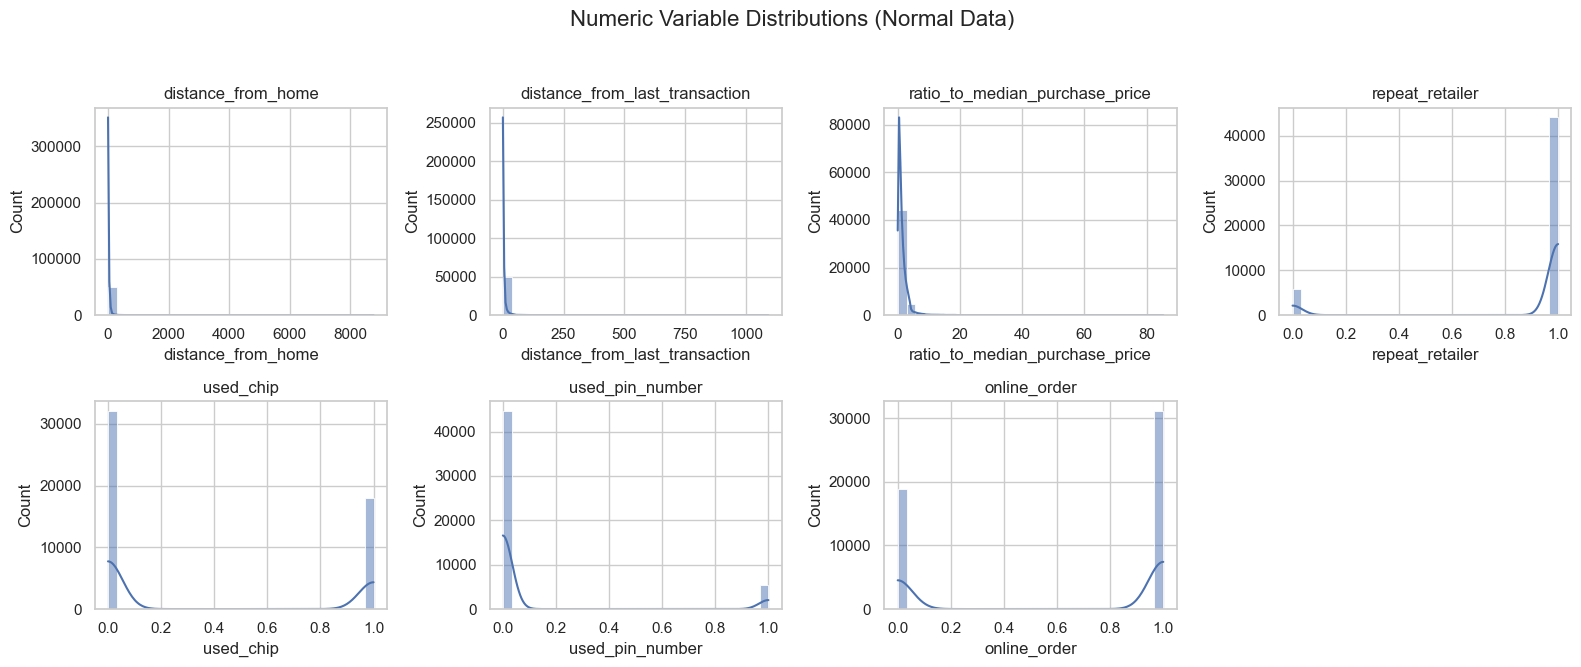

In [19]:
# 정상 데이터만 사용한 EDA

df_normal = df_sampled[df_sampled['fraud']==0].copy()

# 예: 기본 정보
print("===== Normal Data Basic Info =====")
print("Number of samples:", df_normal.shape[0])
print("Number of variables:", df_normal.shape[1])
print("\nColumn names and types:")
print(df_normal.dtypes)
print("\nMissing values per column:")
print(df_normal.isnull().sum())

# 기술 통계
print("\n===== Descriptive Statistics (Normal Data) =====")
print(df_normal.describe().T)

# 이상치 탐색 (IQR)
numeric_cols = df_normal.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "fraud"]
outlier_summary = {}
for col in numeric_cols:
    Q1 = df_normal[col].quantile(0.25)
    Q3 = df_normal[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df_normal[(df_normal[col] < lower) | (df_normal[col] > upper)]
    outlier_summary[col] = len(outliers)
outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['# Outliers'])
print(outlier_df)

# 변수별 분포
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols)/n_cols))
plt.figure(figsize=(n_cols*4, n_rows*3.5))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df_normal[col], bins=30, kde=True)
    plt.title(col)
plt.suptitle("Numeric Variable Distributions (Normal Data)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


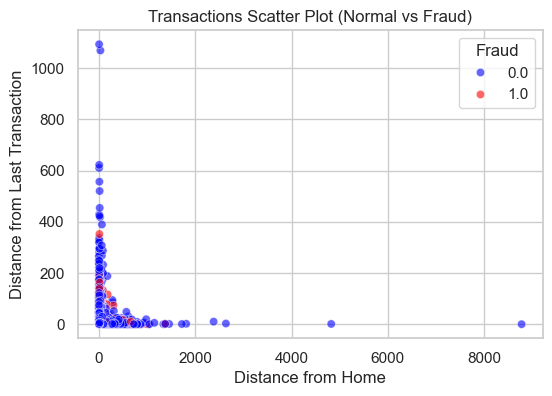

In [22]:
# 정상 데이터와 이상치 모두 사용

plt.figure(figsize=(6,4))

# 임의의 변수 선택 (distance_from_home, distance_from_last_transaction)
sns.scatterplot(x='distance_from_home', 
                y='distance_from_last_transaction', 
                hue='fraud',  # fraud=0,1에 따라 색상 구분
                palette={0:'blue', 1:'red'},
                alpha=0.6,
                data=df_sampled)  # 전체 데이터 사용

plt.title("Transactions Scatter Plot (Normal vs Fraud)")
plt.xlabel("Distance from Home")
plt.ylabel("Distance from Last Transaction")
plt.legend(title='Fraud')
plt.show()


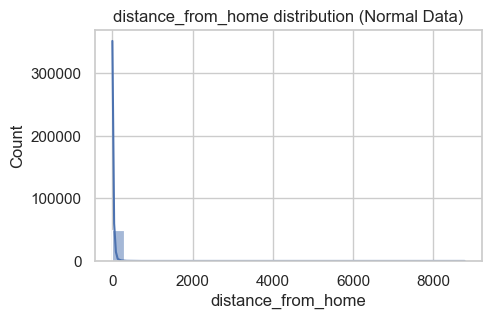

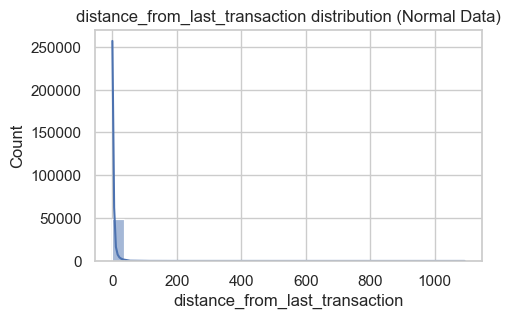

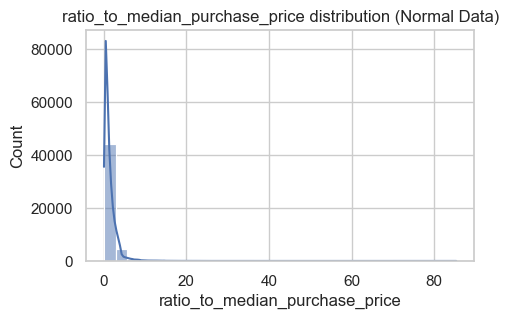

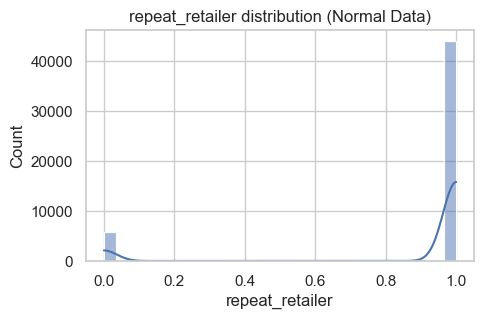

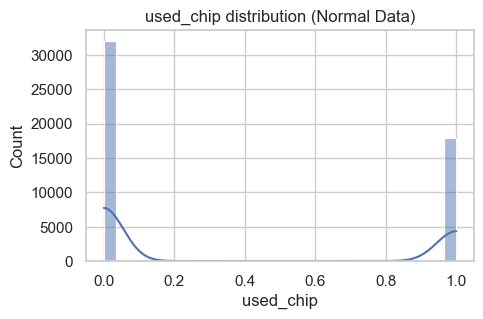

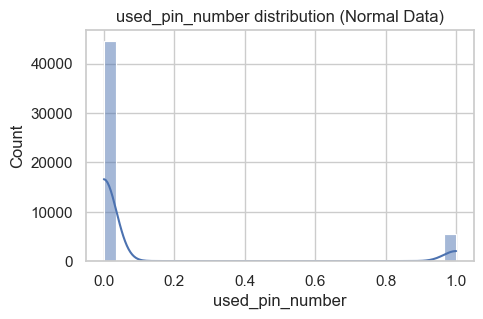

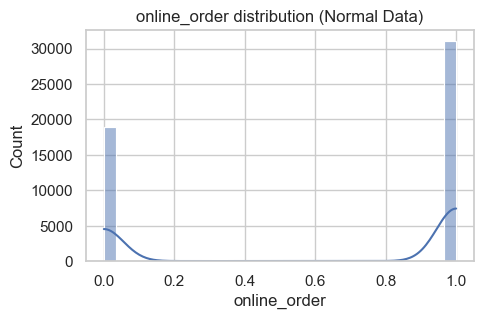

In [21]:
# 변수별 분호 확인
for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df_normal[col], bins=30, kde=True)
    plt.title(f"{col} distribution (Normal Data)")
    plt.show()


#### 

### 이상탐지 알고리즘 비교실험

#### 1. KDE
정상 데이터의 70%만 학습에 사용  
나머지 데이터(정상 데이터의 30% + 이상치 데이터)를 테스트 데이터로 사용  

Train (normal only) shape: (35000, 7)
Test shape: (16000, 7)  (normals: 15000 , anomalies: 1000 )
Best bandwidth: 10.0
ROC AUC (novelty): 0.7301784
EER ~ 0.3710 at threshold (novelty) = 23.5327
Confusion matrix @threshold:
TN, FP, FN, TP = 9436 5564 371 629
FAR (FPR) = 0.3709, FRR (FNR) = 0.3710


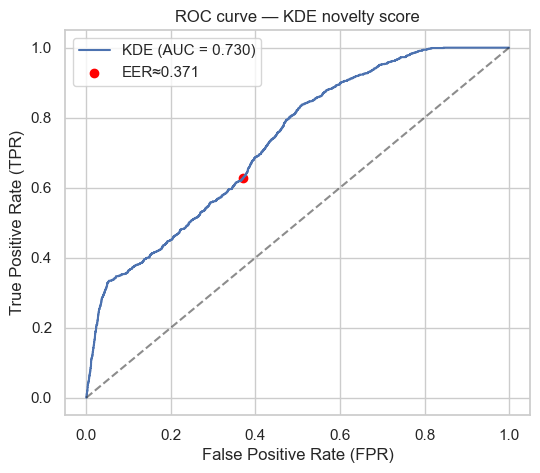


=== KDE summary ===
Train: normals only, 35000 samples
Test: 16000 samples (15000 normals, 1000 anomalies)
Best bandwidth: 10.0
ROC-AUC: 0.7302
EER (approx): 0.3710
FAR @EER-threshold: 0.3709, FRR @EER-threshold: 0.3710


In [23]:
# KDE anomaly detection — train on normals only, test on normals+anomalies
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KernelDensity
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt

# -------------------------
# 0) 전제: df_sampled이 이미 메모리에 있음
# columns include numeric features and 'fraud' (0/1)
# -------------------------

# 1) 분할: 정상만 뽑아서 train/test 분할
df_normal = df_sampled[df_sampled['fraud'] == 0].copy()
df_anom   = df_sampled[df_sampled['fraud'] == 1].copy()

# 비율 설정
train_frac = 0.70  # 정상의 70%를 학습에 사용
# 정상 train / normal_test
normal_train, normal_test = train_test_split(df_normal, train_size=train_frac, random_state=42, shuffle=True)

# test 세트는 normal_test + 모든 anomalies
test_df = pd.concat([normal_test, df_anom], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

# 학습에서 사용할 feature 컬럼들 (fraud 제외)
feature_cols = [c for c in df_sampled.columns if c != 'fraud']

X_train = normal_train[feature_cols].values
X_test  = test_df[feature_cols].values
y_test  = test_df['fraud'].astype(int).values  # 0=normal, 1=anomaly

print("Train (normal only) shape:", X_train.shape)
print("Test shape:", X_test.shape, " (normals:", (y_test==0).sum(), ", anomalies:", (y_test==1).sum(), ")")

# 2) bandwidth 탐색 (간단한 그리드)
bandwidths = np.logspace(-1, 1, 10)  # 예: 0.1 ~ 10 범위
grid = GridSearchCV(KernelDensity(kernel='gaussian'), {'bandwidth': bandwidths}, cv=3, n_jobs=-1)
grid.fit(X_train)

best_bw = grid.best_params_['bandwidth']
print("Best bandwidth:", best_bw)

# 최종 KDE 모델
kde = KernelDensity(bandwidth=best_bw, kernel='gaussian')
kde.fit(X_train)

# 3) 테스트 샘플에 대한 density (로그밀도) 계산
log_density_test = kde.score_samples(X_test)  # 더 큰 값 = 더 높은 밀도(정상)
# novelty score (anomaly score) — 밀도가 낮을수록 이상 가능성 높음
novelty_score = -log_density_test  # 높을수록 더 이상함

# 4) ROC, AUC 계산 (anom=1로 봄)
fpr, tpr, thresholds = roc_curve(y_test, novelty_score)  # use novelty_score so higher -> anomaly
roc_auc = auc(fpr, tpr)
print("ROC AUC (novelty):", roc_auc)

# 5) EER 계산 (FNR ~= FPR)
fnr = 1 - tpr
# find threshold where abs(FPR - FNR) minimal
eer_idx = np.nanargmin(np.abs(fpr - fnr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2.0
eer_threshold = thresholds[eer_idx]
print(f"EER ~ {eer:.4f} at threshold (novelty) = {eer_threshold:.4f}")

# 6) example choose threshold (e.g., threshold at desired FPR or at EER)
threshold = eer_threshold  # 여기서는 EER 기준 threshold 사용

# 예측 (novelty_score >= threshold -> anomaly)
y_pred = (novelty_score >= threshold).astype(int)

# confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
FAR = fp / (fp + tn) if (fp + tn) > 0 else 0.0  # false alarm rate == FPR
FRR = fn / (fn + tp) if (fn + tp) > 0 else 0.0  # false rejection rate == FNR (miss rate)
print("Confusion matrix @threshold:")
print("TN, FP, FN, TP =", tn, fp, fn, tp)
print(f"FAR (FPR) = {FAR:.4f}, FRR (FNR) = {FRR:.4f}")

# 7) ROC plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"KDE (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.scatter([fpr[eer_idx]], [tpr[eer_idx]], color='red', label=f"EER≈{eer:.3f}")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC curve — KDE novelty score")
plt.legend()
plt.grid(True)
plt.show()

# 8) 모델 및 평가지표 요약 출력
print("\n=== KDE summary ===")
print(f"Train: normals only, {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples ({(y_test==0).sum()} normals, {(y_test==1).sum()} anomalies)")
print(f"Best bandwidth: {best_bw}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"EER (approx): {eer:.4f}")
print(f"FAR @EER-threshold: {FAR:.4f}, FRR @EER-threshold: {FRR:.4f}")


#### 2. LoF(Localty of Factor)

LOF: Train (normal only): (35000, 7)
LOF: Test (normal+anomaly): (16000, 7) normals: 15000 anoms: 1000
ROC AUC (LOF novelty): 0.9899562666666667
EER ~ 0.0471 at threshold=-0.2363
Confusion @EER-threshold -> TN, FP, FN, TP: 14293 707 47 953
FAR (FPR) = 0.0471, FRR (FNR) = 0.0470


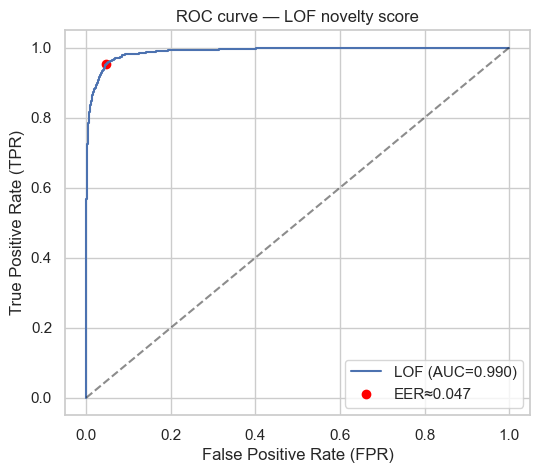


=== LOF summary ===
Train on normals only: 35000 samples
Test: 16000 samples (15000 normals, 1000 anomalies)
LOF params: n_neighbors=20
ROC-AUC: 0.9900
EER (approx): 0.0471
FAR @EER-threshold: 0.0471, FRR @EER-threshold: 0.0470


In [24]:
# LOF (Local Outlier Factor) - novelty detection mode
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_curve, auc, confusion_matrix

# -------------------------
# 전제: df_sampled이 이미 메모리에 있음
# -------------------------

# 1) 데이터 분할: 정상만 train, test = normal_test + all anomalies
df_normal = df_sampled[df_sampled['fraud'] == 0].copy()
df_anom   = df_sampled[df_sampled['fraud'] == 1].copy()

train_frac = 0.70
normal_train, normal_test = train_test_split(df_normal, train_size=train_frac, random_state=42, shuffle=True)
test_df = pd.concat([normal_test, df_anom], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

feature_cols = [c for c in df_sampled.columns if c != 'fraud']

X_train = normal_train[feature_cols].values
X_test  = test_df[feature_cols].values
y_test  = test_df['fraud'].astype(int).values  # 0 normal, 1 anomaly

print("LOF: Train (normal only):", X_train.shape)
print("LOF: Test (normal+anomaly):", X_test.shape, "normals:", (y_test==0).sum(), "anoms:", (y_test==1).sum())

# 2) Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 3) LOF 모델 (novelty=True allows calling decision_function on new data)
#    n_neighbors는 데이터 크기/차원에 따라 조절 가능; 기본 20
lof = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination='auto')
lof.fit(X_train_scaled)  # 학습은 정상 데이터만

# 4) anomaly / novelty score
# decision_function: higher -> inlier (normal). We invert so higher -> more anomalous
dec_func = lof.decision_function(X_test_scaled)   # larger = more normal
novelty_score = -dec_func                          # larger = more anomalous

# 5) ROC, AUC
fpr, tpr, thresholds = roc_curve(y_test, novelty_score)
roc_auc = auc(fpr, tpr)
print("ROC AUC (LOF novelty):", roc_auc)

# 6) EER (approx)
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fpr - fnr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2.0
eer_thr = thresholds[eer_idx]
print(f"EER ~ {eer:.4f} at threshold={eer_thr:.4f}")

# 7) threshold 기반 예측 및 혼동행렬
thr = eer_thr
y_pred = (novelty_score >= thr).astype(int)  # 1 = anomaly
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

FAR = fp / (fp + tn) if (fp + tn) > 0 else 0.0  # False Alarm Rate (FPR)
FRR = fn / (fn + tp) if (fn + tp) > 0 else 0.0  # False Rejection Rate (FNR)
print("Confusion @EER-threshold -> TN, FP, FN, TP:", tn, fp, fn, tp)
print(f"FAR (FPR) = {FAR:.4f}, FRR (FNR) = {FRR:.4f}")

# 8) ROC plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"LOF (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.scatter([fpr[eer_idx]], [tpr[eer_idx]], color='red', label=f"EER≈{eer:.3f}")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC curve — LOF novelty score")
plt.legend()
plt.grid(True)
plt.show()

# 9) 요약 출력
print("\n=== LOF summary ===")
print(f"Train on normals only: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples ({(y_test==0).sum()} normals, {(y_test==1).sum()} anomalies)")
print(f"LOF params: n_neighbors={lof.n_neighbors}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"EER (approx): {eer:.4f}")
print(f"FAR @EER-threshold: {FAR:.4f}, FRR @EER-threshold: {FRR:.4f}")


#### 3. GMM

GMM: Train (normal only): (35000, 7)
GMM: Test (normal+anomaly): (16000, 7) normals: 15000 anoms: 1000
Selected n_components (BIC): 10


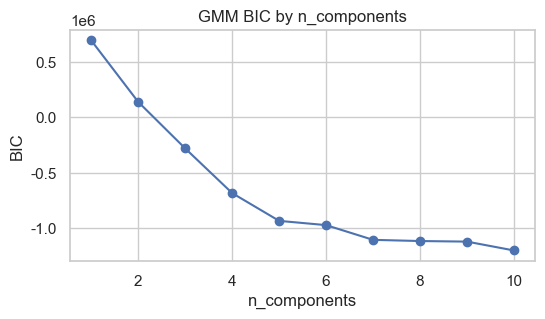

ROC AUC (GMM novelty): 0.9163406666666666
EER ~ 0.1500 at threshold (novelty) = -14.3214
Confusion matrix @EER-threshold -> TN, FP, FN, TP: 12749 2251 150 850
FAR (FPR) = 0.1501, FRR (FNR) = 0.1500


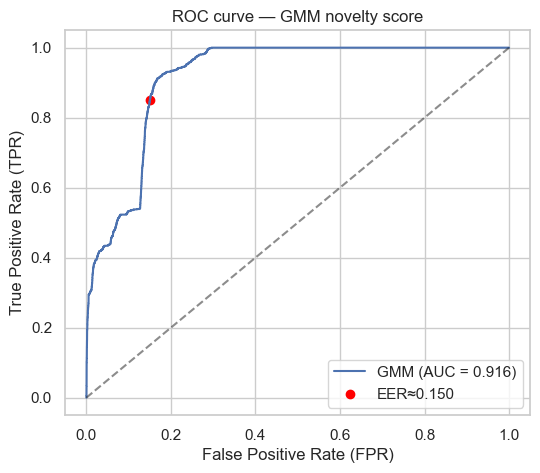


=== GMM summary ===
Train: normals only, 35000 samples
Test: 16000 samples (15000 normals, 1000 anomalies)
Selected n_components (BIC): 10
Covariance type: full
ROC-AUC: 0.9163
EER (approx): 0.1500
FAR @EER-threshold: 0.1501, FRR @EER-threshold: 0.1500


In [26]:
# GMM-based anomaly detection (train on normals only)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_curve, auc, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# 전제: df_sampled (pandas DataFrame) 이 이미 메모리에 있음
# 'fraud' 컬럼이 0/1 레이블
# -------------------------

# 1) 데이터 분할: 정상만 train, test = normal_test + all anomalies
df_normal = df_sampled[df_sampled['fraud'] == 0].copy()
df_anom   = df_sampled[df_sampled['fraud'] == 1].copy()

train_frac = 0.70
normal_train, normal_test = train_test_split(df_normal, train_size=train_frac, random_state=42, shuffle=True)
test_df = pd.concat([normal_test, df_anom], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

feature_cols = [c for c in df_sampled.columns if c != 'fraud']
X_train = normal_train[feature_cols].values
X_test  = test_df[feature_cols].values
y_test  = test_df['fraud'].astype(int).values  # 0 normal, 1 anomaly

print("GMM: Train (normal only):", X_train.shape)
print("GMM: Test (normal+anomaly):", X_test.shape, "normals:", (y_test==0).sum(), "anoms:", (y_test==1).sum())

# 2) Scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# 3) n_components 선택: BIC 기준으로 1..10
lowest_bic = np.inf
best_gmm = None
bic_list = []
n_components_range = range(1, 11)
for n in n_components_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42, n_init=3)
    gmm.fit(X_train_s)
    bic = gmm.bic(X_train_s)
    bic_list.append(bic)
    if bic < lowest_bic:
        lowest_bic = bic
        best_gmm = gmm
print("Selected n_components (BIC):", best_gmm.n_components)
# optional: plot BIC curve
plt.figure(figsize=(6,3))
plt.plot(list(n_components_range), bic_list, marker='o')
plt.title("GMM BIC by n_components")
plt.xlabel("n_components")
plt.ylabel("BIC")
plt.show()

# 4) 로그밀도 계산 -> novelty score
log_density_test = best_gmm.score_samples(X_test_s)  # higher -> more likely normal
novelty_score = -log_density_test                        # higher -> more anomalous

# 5) ROC / AUC
fpr, tpr, thresholds = roc_curve(y_test, novelty_score)
roc_auc = auc(fpr, tpr)
print("ROC AUC (GMM novelty):", roc_auc)

# 6) EER (approx)
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fpr - fnr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2.0
eer_thr = thresholds[eer_idx]
print(f"EER ~ {eer:.4f} at threshold (novelty) = {eer_thr:.4f}")

# 7) threshold 기반 예측 및 혼동행렬
threshold = eer_thr
y_pred = (novelty_score >= threshold).astype(int)  # 1 = anomaly

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
FAR = fp / (fp + tn) if (fp + tn) > 0 else 0.0  # False Alarm Rate (FPR)
FRR = fn / (fn + tp) if (fn + tp) > 0 else 0.0  # False Rejection Rate (FNR)
print("Confusion matrix @EER-threshold -> TN, FP, FN, TP:", tn, fp, fn, tp)
print(f"FAR (FPR) = {FAR:.4f}, FRR (FNR) = {FRR:.4f}")

# 8) ROC plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"GMM (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.scatter([fpr[eer_idx]], [tpr[eer_idx]], color='red', label=f"EER≈{eer:.3f}")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC curve — GMM novelty score")
plt.legend()
plt.grid(True)
plt.show()

# 9) 모델 요약
print("\n=== GMM summary ===")
print(f"Train: normals only, {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples ({(y_test==0).sum()} normals, {(y_test==1).sum()} anomalies)")
print(f"Selected n_components (BIC): {best_gmm.n_components}")
print(f"Covariance type: {best_gmm.covariance_type}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"EER (approx): {eer:.4f}")
print(f"FAR @EER-threshold: {FAR:.4f}, FRR @EER-threshold: {FRR:.4f}")


#### 4. PCA
PCA는 선형 축소라서 비선형 이상 패턴에는 한계가 있음.  
-> AUtoencoder나 Kernel PCA 등을 사용

Train (normal only): (35000, 7)
Test (normal+anomaly): (16000, 7) normals: 15000 anoms: 1000
Chosen n_components = 7 (cumulative explained var at this n = 1.000)
Train reconstruction MSE (mean, std, median): 1.2066390777071705e-30 1.1008926354947968e-29 4.0108866756110175e-31
ROC AUC (PCA reconstruction): 0.6991106666666667
EER ~ 0.3559 at threshold = 0.000000
Confusion matrix @EER-threshold -> TN, FP, FN, TP: 9662 5338 356 644
FAR (FPR) = 0.3559, FRR (FNR) = 0.3560


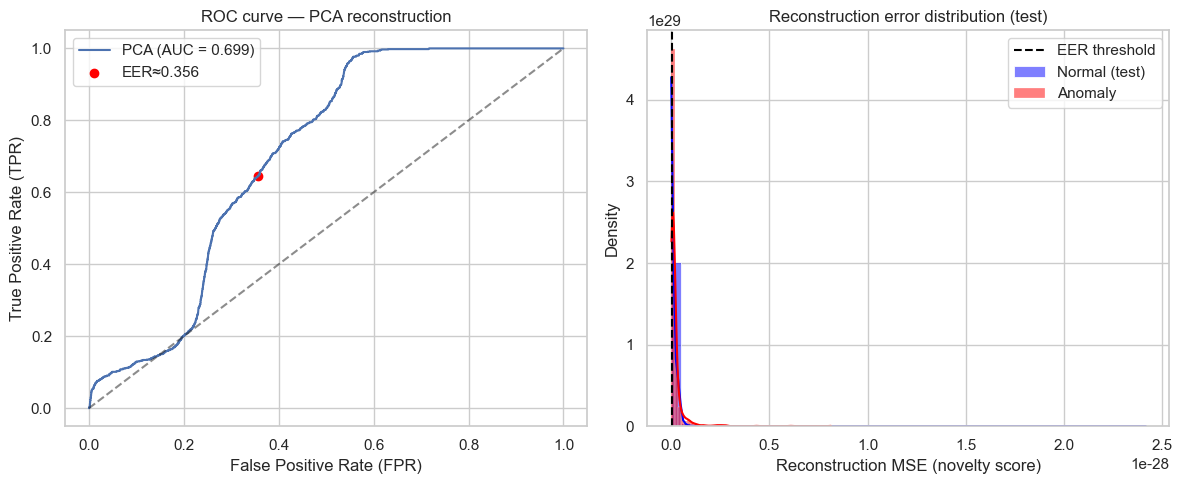


=== PCA Anomaly Detection Summary ===
Train: normals only, 35000 samples
Test: 16000 samples (15000 normals, 1000 anomalies)
PCA n_components: 7, explained_variance: 1.0000
ROC-AUC: 0.6991
EER (approx): 0.3559
FAR @EER-threshold: 0.3559, FRR @EER-threshold: 0.3560


In [27]:
# PCA-based anomaly detection (reconstruction error)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc, confusion_matrix
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# -------------------------
# 전제: df_sampled (pandas DataFrame) 이 이미 메모리에 있음
# 'fraud' 컬럼은 0(normal) / 1(anomaly)
# -------------------------

# --- 1) 데이터 분할: normal-only train, test = normal_test + all anomalies
df_normal = df_sampled[df_sampled['fraud'] == 0].copy()
df_anom   = df_sampled[df_sampled['fraud'] == 1].copy()

train_frac = 0.70
normal_train, normal_test = train_test_split(df_normal, train_size=train_frac, random_state=42, shuffle=True)

test_df = pd.concat([normal_test, df_anom], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

feature_cols = [c for c in df_sampled.columns if c != 'fraud']
X_train = normal_train[feature_cols].values
X_test  = test_df[feature_cols].values
y_test  = test_df['fraud'].astype(int).values  # 0 normal, 1 anomaly

print("Train (normal only):", X_train.shape)
print("Test (normal+anomaly):", X_test.shape, "normals:", (y_test==0).sum(), "anoms:", (y_test==1).sum())

# --- 2) 정규화 (important for PCA)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# --- 3) Choose n_components by explained variance (>=95%), but cap to avoid too many comps
pca_full = PCA(n_components=min(X_train_s.shape[1], 20), random_state=42)  # try up to 20 components
pca_full.fit(X_train_s)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_comp = int(np.searchsorted(cum_var, 0.95) + 1)  # first index where cum_var >= 0.95
n_comp = min(n_comp, 10, X_train_s.shape[1])     # cap by 10 (practical) and feature count
print(f"Chosen n_components = {n_comp} (cumulative explained var at this n = {cum_var[n_comp-1]:.3f})")

# final PCA
pca = PCA(n_components=n_comp, random_state=42)
X_train_p = pca.fit_transform(X_train_s)
X_train_recon = pca.inverse_transform(X_train_p)

# reconstruction error on train (for inspection)
recon_err_train = np.mean((X_train_s - X_train_recon)**2, axis=1)
print("Train reconstruction MSE (mean, std, median):", recon_err_train.mean(), recon_err_train.std(), np.median(recon_err_train))

# apply to test set
X_test_p = pca.transform(X_test_s)
X_test_recon = pca.inverse_transform(X_test_p)
recon_err_test = np.mean((X_test_s - X_test_recon)**2, axis=1)  # novelty score: higher => more anomalous

# --- 4) ROC, AUC, EER
fpr, tpr, thresholds = roc_curve(y_test, recon_err_test)  # recon_err_test: larger -> anomaly
roc_auc = auc(fpr, tpr)
print("ROC AUC (PCA reconstruction):", roc_auc)

fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fpr - fnr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2.0
eer_threshold = thresholds[eer_idx]
print(f"EER ~ {eer:.4f} at threshold = {eer_threshold:.6f}")

# --- 5) threshold 예측 및 혼동행렬 (use EER threshold)
threshold = eer_threshold
y_pred = (recon_err_test >= threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
FAR = fp / (fp + tn) if (fp + tn) > 0 else 0.0
FRR = fn / (fn + tp) if (fn + tp) > 0 else 0.0
print("Confusion matrix @EER-threshold -> TN, FP, FN, TP:", tn, fp, fn, tp)
print(f"FAR (FPR) = {FAR:.4f}, FRR (FNR) = {FRR:.4f}")

# --- 6) 시각화: ROC & reconstruction error distribution
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"PCA (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.scatter([fpr[eer_idx]], [tpr[eer_idx]], color='red', label=f"EER≈{eer:.3f}")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC curve — PCA reconstruction")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
# show histograms of reconstruction error by class
sns.histplot(recon_err_test[y_test==0], label='Normal (test)', kde=True, stat='density', bins=50, color='blue', alpha=0.5)
sns.histplot(recon_err_test[y_test==1], label='Anomaly', kde=True, stat='density', bins=50, color='red', alpha=0.5)
plt.axvline(threshold, color='black', linestyle='--', label='EER threshold')
plt.xlabel("Reconstruction MSE (novelty score)")
plt.title("Reconstruction error distribution (test)")
plt.legend()

plt.tight_layout()
plt.show()

# --- 7) 요약 출력
print("\n=== PCA Anomaly Detection Summary ===")
print(f"Train: normals only, {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples ({(y_test==0).sum()} normals, {(y_test==1).sum()} anomalies)")
print(f"PCA n_components: {n_comp}, explained_variance: {cum_var[n_comp-1]:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"EER (approx): {eer:.4f}")
print(f"FAR @EER-threshold: {FAR:.4f}, FRR @EER-threshold: {FRR:.4f}")


#### 5. Autoencoder

AE: Train (normal only): (35000, 7)
AE: Test (normal+anomaly): (16000, 7) normals: 15000 anoms: 1000


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                   ┃ Output Shape            ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)       │ (None, 7)               │            0 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ dense (Dense)                  │ (None, 64)              │          512 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ dense_1 (Dense)                │ (None, 32)              │        2,080 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ dense_2 (Dense)                │ (None, 16)              │          528 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ dense_3 (Dense)                │ (None, 32)              │          544 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ dense_4 (Dense)                │ (None, 64)              │        2,112 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ dense_5 (Dense)                │ (None, 7)               │          455 │
└────────────────────────────────┴─────────────────────────┴──────────────┘

 Total params: 6,231 (24.34 KB)

 Trainable params: 6,231 (24.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
124/124 - 5s - 43ms/step - loss: 0.4487 - val_loss: 0.1207
Epoch 2/100
124/124 - 1s - 10ms/step - loss: 0.0297 - val_loss: 0.0083
Epoch 3/100
124/124 - 1s - 9ms/step - loss: 0.0077 - val_loss: 0.0046
Epoch 4/100
124/124 - 1s - 9ms/step - loss: 0.0048 - val_loss: 0.0029
Epoch 5/100
124/124 - 1s - 8ms/step - loss: 0.0030 - val_loss: 0.0021
Epoch 6/100
124/124 - 1s - 9ms/step - loss: 0.0023 - val_loss: 0.0016
Epoch 7/100
124/124 - 1s - 8ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 8/100
124/124 - 1s - 8ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 9/100
124/124 - 1s - 9ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 10/100
124/124 - 1s - 8ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 11/100
124/124 - 1s - 8ms/step - loss: 0.0018 - val_loss: 0.0010
Epoch 12/100
124/124 - 1s - 9ms/step - loss: 0.0013 - val_loss: 8.0703e-04
Epoch 13/100
124/124 - 1s - 9ms/step - loss: 9.8136e-04 - val_loss: 7.4765e-04
Epoch 14/100
124/124 - 1s - 10ms/step - loss: 0.0011 - val_loss: 7.4010e

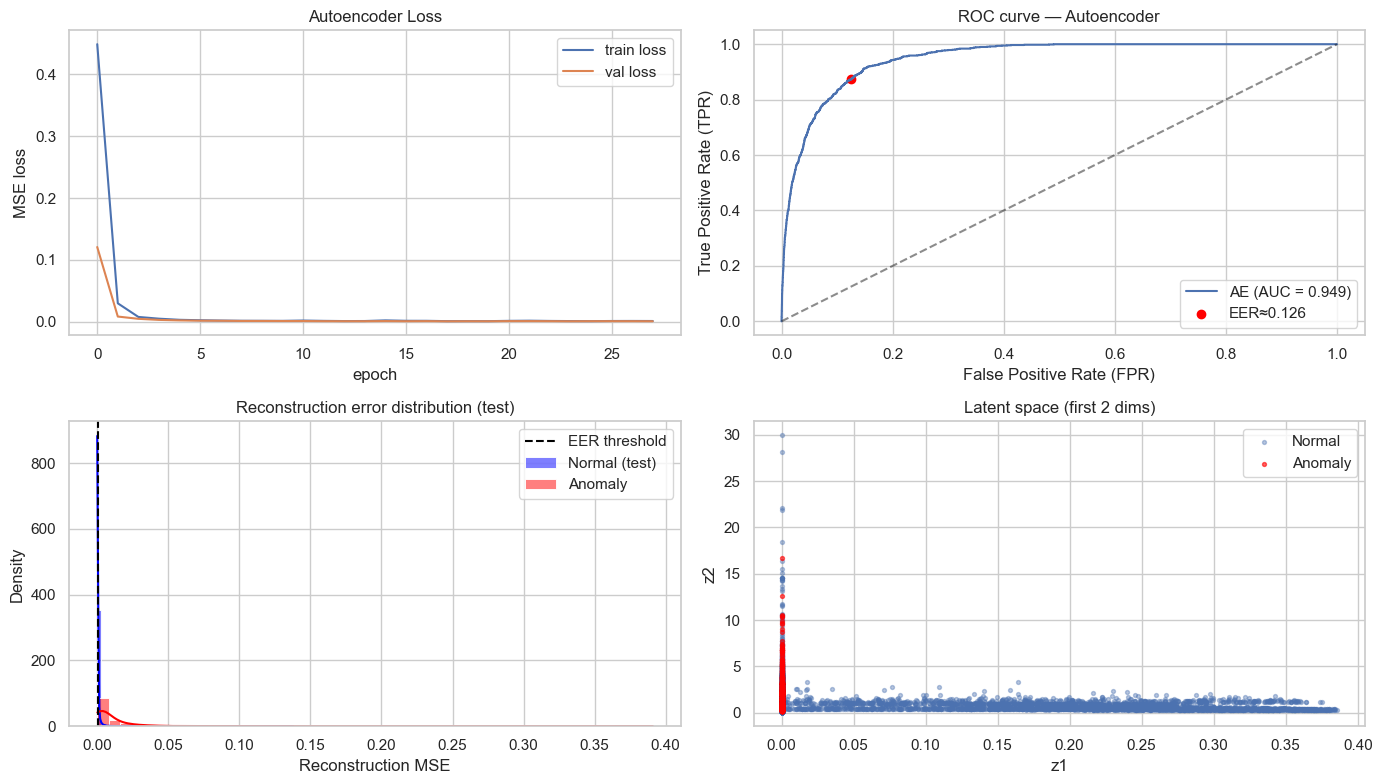


=== Autoencoder summary ===
Train: normals only, 35000 samples
Test: 16000 samples (15000 normals, 1000 anomalies)
AE architecture: input=7, latent=16
ROC-AUC: 0.9486
EER (approx): 0.1259
FAR @EER-threshold: 0.1259, FRR @EER-threshold: 0.1260


In [29]:
# Autoencoder-based anomaly detection (train on normals only)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# reproducibility (somewhat)
import random
random.seed(42)
np.random.seed(42)

# TensorFlow / Keras
import tensorflow as tf
tf.random.set_seed(42)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, confusion_matrix

# -------------------------
# 전제: df_sampled (pandas DataFrame) 이 이미 메모리에 있음
# 'fraud' 컬럼이 0(normal) / 1(anomaly)
# -------------------------

# 1) 분할: 정상만 train, test = normal_test + all anomalies
df_normal = df_sampled[df_sampled['fraud'] == 0].copy()
df_anom   = df_sampled[df_sampled['fraud'] == 1].copy()

train_frac = 0.70
normal_train, normal_test = train_test_split(df_normal, train_size=train_frac, random_state=42, shuffle=True)

test_df = pd.concat([normal_test, df_anom], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

feature_cols = [c for c in df_sampled.columns if c != 'fraud']
X_train = normal_train[feature_cols].values
X_test  = test_df[feature_cols].values
y_test  = test_df['fraud'].astype(int).values  # 0 normal, 1 anomaly

print("AE: Train (normal only):", X_train.shape)
print("AE: Test (normal+anomaly):", X_test.shape, "normals:", (y_test==0).sum(), "anoms:", (y_test==1).sum())

# 2) Scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# 3) Autoencoder 모델 정의
input_dim = X_train_s.shape[1]
encoding_dim_1 = 64
encoding_dim_2 = 32
latent_dim = 16

inp = Input(shape=(input_dim,))
x = Dense(encoding_dim_1, activation='relu')(inp)
x = Dense(encoding_dim_2, activation='relu')(x)
z = Dense(latent_dim, activation='relu')(x)   # latent

x = Dense(encoding_dim_2, activation='relu')(z)
x = Dense(encoding_dim_1, activation='relu')(x)
out = Dense(input_dim, activation='linear')(x)

autoencoder = Model(inputs=inp, outputs=out)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

# 4) 학습
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, mode='min')
history = autoencoder.fit(
    X_train_s, X_train_s,
    epochs=100,
    batch_size=256,
    validation_split=0.1,
    callbacks=[es],
    verbose=2
)

# 5) 재구성오차 계산 (train / test)
X_train_recon = autoencoder.predict(X_train_s)
recon_err_train = np.mean(np.square(X_train_s - X_train_recon), axis=1)

X_test_recon = autoencoder.predict(X_test_s)
recon_err_test = np.mean(np.square(X_test_s - X_test_recon), axis=1)  # novelty score (higher => anomaly)

print("Train recon err mean/std/median:", recon_err_train.mean(), recon_err_train.std(), np.median(recon_err_train))

# 6) ROC, AUC
fpr, tpr, thresholds = roc_curve(y_test, recon_err_test)
roc_auc = auc(fpr, tpr)
print("ROC AUC (Autoencoder recon error):", roc_auc)

# 7) EER 계산 (approx)
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fpr - fnr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2.0
eer_threshold = thresholds[eer_idx]
print(f"EER ~ {eer:.4f} at threshold = {eer_threshold:.6f}")

# 8) threshold 기반 예측 및 혼동행렬 (EER threshold 사용)
threshold = eer_threshold
y_pred = (recon_err_test >= threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
FAR = fp / (fp + tn) if (fp + tn) > 0 else 0.0  # False Alarm Rate (FPR)
FRR = fn / (fn + tp) if (fn + tp) > 0 else 0.0  # False Rejection Rate (FNR)

print("Confusion matrix @EER-threshold -> TN, FP, FN, TP:", tn, fp, fn, tp)
print(f"FAR (FPR) = {FAR:.4f}, FRR (FNR) = {FRR:.4f}")

# 9) 시각화: loss curve, ROC, recon error distributions
plt.figure(figsize=(14,8))

plt.subplot(2,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Autoencoder Loss')
plt.xlabel('epoch'); plt.ylabel('MSE loss'); plt.legend()

plt.subplot(2,2,2)
plt.plot(fpr, tpr, label=f"AE (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.scatter([fpr[eer_idx]], [tpr[eer_idx]], color='red', label=f"EER≈{eer:.3f}")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC curve — Autoencoder")
plt.legend()

plt.subplot(2,2,3)
sns.histplot(recon_err_test[y_test==0], label='Normal (test)', kde=True, stat='density', color='blue', bins=50, alpha=0.5)
sns.histplot(recon_err_test[y_test==1], label='Anomaly', kde=True, stat='density', color='red', bins=50, alpha=0.5)
plt.axvline(threshold, color='black', linestyle='--', label='EER threshold')
plt.title("Reconstruction error distribution (test)")
plt.xlabel("Reconstruction MSE")
plt.legend()

plt.subplot(2,2,4)
# latent space visualization (optional) - encode via intermediate model if needed
# We'll compute encoded representations by creating encoder model quickly
encoder = Model(inputs=inp, outputs=z)
Z_test = encoder.predict(X_test_s)
if Z_test.shape[1] >= 2:
    plt.scatter(Z_test[y_test==0,0], Z_test[y_test==0,1], s=8, alpha=0.4, label='Normal')
    plt.scatter(Z_test[y_test==1,0], Z_test[y_test==1,1], s=8, alpha=0.6, label='Anomaly', color='red')
    plt.xlabel("z1"); plt.ylabel("z2"); plt.title("Latent space (first 2 dims)")
    plt.legend()
else:
    plt.text(0.1, 0.5, "Latent dim <2, skip", fontsize=12)

plt.tight_layout()
plt.show()

# 10) 요약 출력
print("\n=== Autoencoder summary ===")
print(f"Train: normals only, {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples ({(y_test==0).sum()} normals, {(y_test==1).sum()} anomalies)")
print(f"AE architecture: input={input_dim}, latent={latent_dim}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"EER (approx): {eer:.4f}")
print(f"FAR @EER-threshold: {FAR:.4f}, FRR @EER-threshold: {FRR:.4f}")


#### 모델의 결과 비교

| 모델              | ROC-AUC    | EER       | 평가       |
| --------------- | ---------- | --------- | -------- |
| **LOF**         | **0.9900** | **0.047** | 🔥 최고 성능 |
| **Autoencoder** | **0.9486** | **0.126** | 👍 매우 좋음 |
| GMM             | 0.9163     | 0.150     | 🙂 좋음    |
| KDE             | 0.730      | 0.371     | 😐 부족    |
| PCA             | 0.699      | 0.356     | ❌ 낮음     |


✅ 2. LOF가 가장 성능이 좋은 이유
🔍 핵심 요약

LOF(Local Outlier Factor)는 “국소 밀도(local density)” 기반이라, 정상 데이터가 촘촘하게 모여 있고, 이상 데이터가 이 군집에서 멀리 떨어져 있을 때 극도로 강함.

→ 비선형 구조를 학습한다기보다는, 데이터의 지역적·비규칙적 패턴을 그대로 보존한 상태에서 밀도 차이를 계산하는 방식이라 성능이 잘 나온 것.

즉, LOF는 학습 모델이 아니라 데이터의 지형(shape) 그대로 이용하는 점이 장점.

=================================================================================

❌ PCA anomaly detection (ROC-AUC 0.69)
🔸 낮은 성능 이유

선형 차원 축소(PCA)라 비선형 구조를 반영 못함
→ 데이터가 선형적인 subspace에 놓여있지 않다면 reconstruction error의 의미가 흐려짐.

explained variance 1.000 → PCA로도 차원이 잘 안 줄었음
→ 즉 데이터가 PCA의 선형 축으로 정리되지 않음.

이상치가 정상 subspace 근처에 있을 경우 PCA가 거의 구별 못함

🔸 요약

데이터가 선형 구조가 아니라 PCA 기반 재구성이 anomaly score로 유효하지 않음 → 낮은 성능.

=================================================================================

❌ KDE (ROC-AUC 0.73)
🔸 낮은 성능 이유

KDE는 고차원 데이터에서 밀도 추정이 매우 어렵고 부정확함
→ 차원 저주 영향.

전역적 밀도(global density)를 하나의 형태로 모델링
→ 복잡한 분포(다중 클러스터, 비선형 분포)에서는 부적합.

bandwidth=10이 best인 상황 = local structure가 잘 안 잡힌 것
→ 즉 “매우 뭉뚱그린 부드러운 분포”만 모델링되었을 가능성.

🔸 요약

데이터의 복잡한 지역적 구조를 표현 못해서 이상치의 밀도 차이가 잘 드러나지 않음

=================================================================================

🙂 GMM (ROC-AUC 0.916)
중상위권이지만 LOF/AE보다는 낮은 이유

GMM은 Gaussian 혼합이라는 가정이 들어감
→ 데이터 분포가 Gaussian cluster 형태가 아니면 한계 발생.

full covariance라도 비선형 경계는 표현 못함

이상 데이터가 Gaussian cluster에서 벗어났더라도
GMM이 그 방향으로 긴 타원을 만들어 커버하려 할 수 있음
→ anomaly score 차이가 LOF보다 덜 선명해짐.

요약

분포 가정 때문에 어느 정도 성능 제한.

=================================================================================

👍 Autoencoder (ROC-AUC 0.948)
좋은 이유

비선형 구조 학습 가능

정상 패턴을 잘 모사 → 이상은 reconstruction error가 큼

latent dimension(16)이 꽤 넉넉하여 정상 구조를 잘 근사

=================================================================================

🎯 최종 결론 요약  
● LOF가 최고 성능인 이유

- 국소 밀도 기반이라 정상 데이터의 실제 구조를 그대로 반영

- 비선형/복잡한 분포에서도 강함

- 분포 가정 없음

- 정상 클러스터가 조밀하고 anomaly가 sparse한 데이터에 최적  

● 성능 낮은 모델들의 패턴

- PCA: 선형성 가정 불일치 → reconstruction error 의미 없음

- KDE: 고차원에서 전역 밀도 추정 실패 → local structure 반영 불가

- GMM: Gaussian 가정으로 인한 한계, 비선형 경계 표현 불가

● 중상위권 모델

- AE: 비선형적 구조 학습 가능, 밀도 기반보다 더 유연

- GMM: 조금 덜 유연하지만 안정

#### 

### 교재 외 이상탐지 알고리즘

In [34]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

RND = 42

# --- split normal/anomaly
df_normal = df_sampled[df_sampled['fraud'] == 0].copy().reset_index(drop=True)
df_anom   = df_sampled[df_sampled['fraud'] == 1].copy().reset_index(drop=True)

# train only normals (use 35000 as example if available; otherwise use fraction)
train_frac = None
if df_normal.shape[0] >= 35000:
    # pick exactly 35000 normals for parity with your earlier experiments
    normal_train = df_normal.sample(n=35000, random_state=RND)
    normal_test = df_normal.drop(normal_train.index).reset_index(drop=True)
else:
    # fallback: 70/30 split
    train_frac = 0.70
    normal_train, normal_test = train_test_split(df_normal, train_size=train_frac, random_state=RND, shuffle=True)

# Compose test set: remaining normals + all anomalies (shuffle)
test_df = pd.concat([normal_test, df_anom], axis=0).sample(frac=1, random_state=RND).reset_index(drop=True)

feature_cols = [c for c in df_sampled.columns if c != 'fraud']
X_train = normal_train[feature_cols].values
X_test  = test_df[feature_cols].values
y_test  = test_df['fraud'].astype(int).values  # 0 normal, 1 anomaly

print("Train (normal only):", X_train.shape)
print("Test (normal+anomaly):", X_test.shape, "normals:", (y_test==0).sum(), "anoms:", (y_test==1).sum())

# Standardize
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Utility: compute ROC, AUC, EER, confusion at EER, print formatted summary
def compute_and_print_scores(scores, y_test, title="Model", summary_template=None, plot=True):
    # scores: higher -> more anomalous
    fpr, tpr, thresholds = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2.0
    eer_threshold = thresholds[eer_idx]

    # confusion at threshold
    y_pred = (scores >= eer_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    FAR = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    FRR = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    if plot:
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f"{title} (AUC = {roc_auc:.4f})")
        plt.plot([0,1],[0,1],'k--', alpha=0.5)
        plt.scatter([fpr[eer_idx]],[tpr[eer_idx]], color='red', label=f"EER≈{eer:.4f}")
        plt.xlabel("False Positive Rate (FPR)")
        plt.ylabel("True Positive Rate (TPR)")
        plt.title(f"ROC curve — {title}")
        plt.legend()
        plt.grid(True)
        plt.show()

    # formatted print (matches your required style block)
    if summary_template is None:
        print(f"\n=== {title} Summary ===")
        print(f"Train: normals only, {X_train.shape[0]} samples")
        print(f"Test: {X_test.shape[0]} samples ({(y_test==0).sum()} normals, {(y_test==1).sum()} anomalies)")
        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"EER (approx): {eer:.4f}")
        print(f"FAR @EER-threshold: {FAR:.4f}, FRR @EER-threshold: {FRR:.4f}")
    else:
        print(summary_template.format(
            train_n=X_train.shape[0],
            test_n=X_test.shape[0],
            normals=(y_test==0).sum(),
            anoms=(y_test==1).sum(),
            roc_auc=roc_auc,
            eer=eer,
            far=FAR,
            frr=FRR
        ))

    return {
        "fpr": fpr, "tpr": tpr, "thresholds": thresholds,
        "roc_auc": roc_auc, "eer": eer, "eer_threshold": eer_threshold,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp, "FAR": FAR, "FRR": FRR
    }


Train (normal only): (35000, 7)
Test (normal+anomaly): (16000, 7) normals: 15000 anoms: 1000


#### 

#### 1. Isolation Forest (메인 + ablation)


--- IsolationForest baseline ---
IF params: {'n_estimators': 100, 'max_samples': 'auto', 'contamination': 'auto', 'random_state': 42}
Train time (s): 0.6382


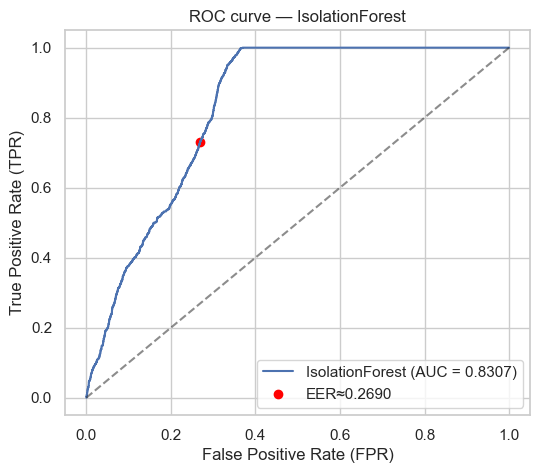


=== IsolationForest Summary ===
Train: normals only, 35000 samples
Test: 16000 samples (15000 normals, 1000 anomalies)
ROC-AUC: 0.8307
EER (approx): 0.2690
FAR @EER-threshold: 0.2691, FRR @EER-threshold: 0.2690

=== IF n_est=50 max_samp=256 Summary ===
Train: normals only, 35000 samples
Test: 16000 samples (15000 normals, 1000 anomalies)
ROC-AUC: 0.8215
EER (approx): 0.2791
FAR @EER-threshold: 0.2792, FRR @EER-threshold: 0.2790
AB: {'n_estimators': 50, 'max_samples': 256, 'contamination': 'auto', 'random_state': 42} => AUC=0.8215, EER=0.2791, FAR=0.2792, FRR=0.2790

=== IF n_est=100 max_samp=256 Summary ===
Train: normals only, 35000 samples
Test: 16000 samples (15000 normals, 1000 anomalies)
ROC-AUC: 0.8307
EER (approx): 0.2690
FAR @EER-threshold: 0.2691, FRR @EER-threshold: 0.2690
AB: {'n_estimators': 100, 'max_samples': 256, 'contamination': 'auto', 'random_state': 42} => AUC=0.8307, EER=0.2690, FAR=0.2691, FRR=0.2690

=== IF n_est=200 max_samp=256 Summary ===
Train: normals only, 

,n_estimators,max_samples,roc_auc,eer,FAR,FRR
0,50,256,0.8215,0.2791,0.2792,0.2790
1,100,256,0.8307,0.2690,0.2691,0.2690
2,200,256,0.8357,0.2681,0.2681,0.2680
3,100,1024,0.8782,0.2223,0.2226,0.2220
4,100,35000,0.9406,0.1191,0.1193,0.1190


In [35]:
# Cell 1: Isolation Forest + ablation
from sklearn.ensemble import IsolationForest
import time

# baseline IF
if_params = dict(n_estimators=100, max_samples='auto', contamination='auto', random_state=RND)
if_model = IsolationForest(**if_params)
t0 = time.time()
if_model.fit(X_train_s)
t1 = time.time()

# anomaly score: use -score_samples (so higher => more anomalous)
scores_if = -if_model.score_samples(X_test_s)

print("\n--- IsolationForest baseline ---")
print("IF params:", if_params)
print("Train time (s):", round(t1-t0,4))
res_if = compute_and_print_scores(scores_if, y_test, title="IsolationForest")

# Ablation: sweep n_estimators, max_samples, contamination (if not known)
ablation_grid = [
    {"n_estimators":50, "max_samples":256},
    {"n_estimators":100, "max_samples":256},
    {"n_estimators":200, "max_samples":256},
    {"n_estimators":100, "max_samples":1024},
    {"n_estimators":100, "max_samples":X_train_s.shape[0]},
]
ablation_results = []
for p in ablation_grid:
    params = dict(n_estimators=p["n_estimators"], max_samples=p["max_samples"], contamination='auto', random_state=RND)
    m = IsolationForest(**params)
    m.fit(X_train_s)
    scores = -m.score_samples(X_test_s)
    out = compute_and_print_scores(scores, y_test, title=f"IF n_est={p['n_estimators']} max_samp={p['max_samples']}", plot=False)
    ablation_results.append((params, out["roc_auc"], out["eer"], out["FAR"], out["FRR"]))
    print(f"AB: {params} => AUC={out['roc_auc']:.4f}, EER={out['eer']:.4f}, FAR={out['FAR']:.4f}, FRR={out['FRR']:.4f}")

# summarize ablation table
ablation_df = pd.DataFrame([{
    "n_estimators":a[0]["n_estimators"],
    "max_samples":a[0]["max_samples"],
    "roc_auc":a[1],
    "eer":a[2],
    "FAR":a[3],
    "FRR":a[4]
} for a in ablation_results])
print("\n--- IsolationForest ablation summary ---")
display(ablation_df)


#### 

#### 2. Normalizing Flows (RealNVP-like using nflows) + ablation

Epoch 1/100  nll=2.311539
Epoch 20/100  nll=-11.321681
Epoch 40/100  nll=-14.761912
Epoch 60/100  nll=-16.273554
Epoch 80/100  nll=-17.914043
Epoch 100/100  nll=-17.415806


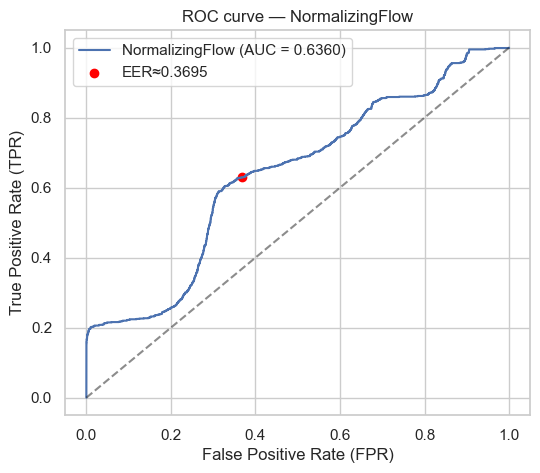


=== NormalizingFlow Summary ===
Train: normals only, 35000 samples
Test: 16000 samples (15000 normals, 1000 anomalies)
ROC-AUC: 0.6360
EER (approx): 0.3695
FAR @EER-threshold: 0.3690, FRR @EER-threshold: 0.3700

ABLA cfg: {'n_layers': 3, 'hidden': 64}

=== NF layers=3 hid=64 Summary ===
Train: normals only, 35000 samples
Test: 16000 samples (15000 normals, 1000 anomalies)
ROC-AUC: 0.7366
EER (approx): 0.3304
FAR @EER-threshold: 0.3298, FRR @EER-threshold: 0.3310
Result AUC=0.7366, EER=0.3304

ABLA cfg: {'n_layers': 4, 'hidden': 128}

=== NF layers=4 hid=128 Summary ===
Train: normals only, 35000 samples
Test: 16000 samples (15000 normals, 1000 anomalies)
ROC-AUC: 0.4821
EER (approx): 0.4959
FAR @EER-threshold: 0.4958, FRR @EER-threshold: 0.4960
Result AUC=0.4821, EER=0.4959

ABLA cfg: {'n_layers': 6, 'hidden': 128}

=== NF layers=6 hid=128 Summary ===
Train: normals only, 35000 samples
Test: 16000 samples (15000 normals, 1000 anomalies)
ROC-AUC: 0.5210
EER (approx): 0.4962
FAR @EER-th

,n_layers,hidden,roc_auc,eer,FAR,FRR
0,3,64,0.7366,0.3304,0.3298,0.3310
1,4,128,0.4821,0.4959,0.4958,0.4960
2,6,128,0.5210,0.4962,0.4964,0.4960


In [36]:
# Cell 2: Normalizing Flow (nflows) for density estimation + ablation
import torch
from torch import nn, optim
from nflows.flows import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform
from nflows.transforms.permutations import ReversePermutation
from nflows.transforms.normalization import BatchNorm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(RND)
np.random.seed(RND)

# Wrap numpy arrays into torch tensors
X_train_t = torch.from_numpy(X_train_s.astype(np.float32)).to(device)
X_test_t  = torch.from_numpy(X_test_s.astype(np.float32)).to(device)

def build_flow(num_features, n_layers=5, hidden_features=64):
    transforms = []
    for i in range(n_layers):
        transforms.append(MaskedAffineAutoregressiveTransform(
            features=num_features,
            hidden_features=hidden_features,
            context_features=None
        ))
        transforms.append(BatchNorm(features=num_features))
        transforms.append(ReversePermutation(features=num_features))
    transform = CompositeTransform(transforms)
    base_dist = StandardNormal((num_features,))
    flow = Flow(transform, base_dist).to(device)
    return flow

# baseline flow
n_features = X_train_s.shape[1]
flow = build_flow(num_features=n_features, n_layers=6, hidden_features=128)
optimizer = optim.Adam(flow.parameters(), lr=1e-3)
n_epochs = 100
batch_size = 256

# training loop (maximize log-likelihood)
flow.train()
for epoch in range(1, n_epochs+1):
    perm = torch.randperm(X_train_t.size(0))
    epoch_loss = 0.0
    for i in range(0, X_train_t.size(0), batch_size):
        idx = perm[i:i+batch_size]
        xb = X_train_t[idx]
        optimizer.zero_grad()
        loss = -flow.log_prob(xb).mean()  # negative log-likelihood
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= X_train_t.size(0)
    if epoch % 20 == 0 or epoch==1 or epoch==n_epochs:
        print(f"Epoch {epoch}/{n_epochs}  nll={epoch_loss:.6f}")

# scoring on test: use negative log likelihood as anomaly score (higher -> more anomalous)
flow.eval()
with torch.no_grad():
    test_logp = flow.log_prob(X_test_t).cpu().numpy()  # higher logp -> more normal
scores_nf = -test_logp  # so higher => more anomalous

res_nf = compute_and_print_scores(scores_nf, y_test, title="NormalizingFlow")

# Ablation: vary n_layers and hidden_features
ablation_configs = [
    {"n_layers":3, "hidden":64},
    {"n_layers":4, "hidden":128},
    {"n_layers":6, "hidden":128},
]
ablation_summary = []
for cfg in ablation_configs:
    print("\nABLA cfg:", cfg)
    f = build_flow(num_features=n_features, n_layers=cfg["n_layers"], hidden_features=cfg["hidden"])
    opt = optim.Adam(f.parameters(), lr=1e-3)
    # quick train (fewer epochs for ablation)
    f.train()
    for epoch in range(1, 51):
        perm = torch.randperm(X_train_t.size(0))
        for i in range(0, X_train_t.size(0), batch_size):
            idx = perm[i:i+batch_size]
            xb = X_train_t[idx]
            opt.zero_grad()
            loss = -f.log_prob(xb).mean()
            loss.backward()
            opt.step()
    f.eval()
    with torch.no_grad():
        lp = f.log_prob(X_test_t).cpu().numpy()
    scores_tmp = -lp
    out = compute_and_print_scores(scores_tmp, y_test, title=f"NF layers={cfg['n_layers']} hid={cfg['hidden']}", plot=False)
    ablation_summary.append((cfg, out["roc_auc"], out["eer"], out["FAR"], out["FRR"]))
    print(f"Result AUC={out['roc_auc']:.4f}, EER={out['eer']:.4f}")

# show ablation table
ablation_nf_df = pd.DataFrame([{
    "n_layers":a[0]["n_layers"],
    "hidden":a[0]["hidden"],
    "roc_auc":a[1],
    "eer":a[2],
    "FAR":a[3],
    "FRR":a[4]
} for a in ablation_summary])
print("\n--- Normalizing Flow ablation summary ---")
display(ablation_nf_df)


#### 3. COPOD (pyod) + ablation

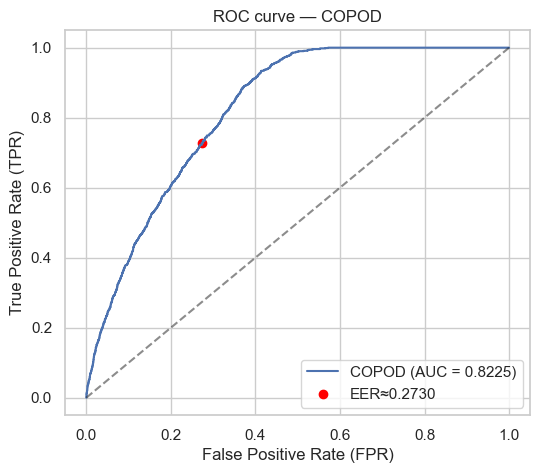


=== COPOD Summary ===
Train: normals only, 35000 samples
Test: 16000 samples (15000 normals, 1000 anomalies)
ROC-AUC: 0.8225
EER (approx): 0.2730
FAR @EER-threshold: 0.2731, FRR @EER-threshold: 0.2730

=== COPOD (standardized) Summary ===
Train: normals only, 35000 samples
Test: 16000 samples (15000 normals, 1000 anomalies)
ROC-AUC: 0.8225
EER (approx): 0.2730
FAR @EER-threshold: 0.2731, FRR @EER-threshold: 0.2730
Ablation COPOD [standardized] => AUC=0.8225, EER=0.2730

=== COPOD (rank transformed) Summary ===
Train: normals only, 35000 samples
Test: 16000 samples (15000 normals, 1000 anomalies)
ROC-AUC: 0.4011
EER (approx): 0.6059
FAR @EER-threshold: 0.6059, FRR @EER-threshold: 0.6060
Ablation COPOD [rank transformed] => AUC=0.4011, EER=0.6059

=== COPOD top7var Summary ===
Train: normals only, 35000 samples
Test: 16000 samples (15000 normals, 1000 anomalies)
ROC-AUC: 0.8225
EER (approx): 0.2730
FAR @EER-threshold: 0.2731, FRR @EER-threshold: 0.2730
COPOD top7var => AUC=0.8225, EER=0

,setting,roc_auc,eer,FAR,FRR
0,standardized,0.8225,0.2730,0.2731,0.2730
1,rank transformed,0.4011,0.6059,0.6059,0.6060
2,top7var,0.8225,0.2730,0.2731,0.2730
3,top5var,0.8825,0.2171,0.2172,0.2170
4,top3var,0.8002,0.2229,0.2279,0.2180


In [37]:
# Cell 3: COPOD using pyod + ablation
from pyod.models.copod import COPOD
from pyod.utils.utility import standardizer

# baseline COPOD
copod = COPOD()
copod.fit(X_train_s)
scores_copod = copod.decision_function(X_test_s)  # higher -> more anomalous

res_copod = compute_and_print_scores(scores_copod, y_test, title="COPOD")

# Ablation: try input transforms / feature subsets / contamination thresholding
ablation_results = []

# 1) different preprocessing: raw standardized vs rank-transform
from scipy import stats
X_train_rank = stats.rankdata(X_train_s, axis=0) / X_train_s.shape[0]
X_test_rank = stats.rankdata(X_test_s, axis=0) / X_train_s.shape[0]

for desc, Xt_train, Xt_test in [
    ("standardized", X_train_s, X_test_s),
    ("rank transformed", X_train_rank, X_test_rank)
]:
    m = COPOD()
    m.fit(Xt_train)
    sc = m.decision_function(Xt_test)
    out = compute_and_print_scores(sc, y_test, title=f"COPOD ({desc})", plot=False)
    ablation_results.append((desc, out["roc_auc"], out["eer"], out["FAR"], out["FRR"]))
    print(f"Ablation COPOD [{desc}] => AUC={out['roc_auc']:.4f}, EER={out['eer']:.4f}")

# 2) feature-subset experiment: drop worst correlated feature or keep top-k by variance
variances = np.var(X_train_s, axis=0)
order = np.argsort(variances)[::-1]  # descending
for k in [7, 5, 3]:  # keep top-k features
    idx = order[:k]
    m = COPOD()
    m.fit(X_train_s[:, idx])
    sc = m.decision_function(X_test_s[:, idx])
    out = compute_and_print_scores(sc, y_test, title=f"COPOD top{str(k)}var", plot=False)
    ablation_results.append((f"top{k}var", out["roc_auc"], out["eer"], out["FAR"], out["FRR"]))
    print(f"COPOD top{k}var => AUC={out['roc_auc']:.4f}, EER={out['eer']:.4f}")

# show ablation summary
copod_ablation_df = pd.DataFrame([{
    "setting":a[0] if isinstance(a[0],str) else str(a[0]),
    "roc_auc":a[1],
    "eer":a[2],
    "FAR":a[3],
    "FRR":a[4]
} for a in ablation_results])
print("\n--- COPOD ablation summary ---")
display(copod_ablation_df)
